## Introduction

Supervised learning is a machine learning approach in which a model learns patterns from labeled data and uses those patterns to make predictions on previously unseen observations. Classification is a supervised learning problem where the objective is to assign observations to predefined categories.

This project focuses on developing a binary classification model for breast cancer diagnosis using the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset contains numerical measurements derived from breast cell nuclei, along with a diagnosis indicating whether a case is benign or malignant. The objective is to build a predictive system capable of distinguishing between these two classes based on the available diagnostic features.

The project follows a complete supervised learning workflow, beginning with dataset inspection and data quality assessment. Exploratory Data Analysis (EDA) is performed to understand feature distributions and relationships with the target variable. The data is then prepared for modeling through target encoding, feature selection, and appropriate preprocessing.

Logistic Regression is implemented as the primary classification model because it is a suitable and interpretable algorithm for binary classification. Random Forest is additionally implemented as a comparison model to evaluate whether a tree-based ensemble approach can provide improved predictive performance.

Model performance is evaluated using multiple metrics, including Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Confusion matrices, ROC curves, feature analysis, and 5-fold stratified cross-validation are also used to provide a comprehensive evaluation of the models. The project concludes with a comparison of the models, error analysis, interpretation of important features, and discussion of the strengths, limitations, and possible improvements of the developed approach.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving wdbc.data to wdbc.data
Saving wdbc.names to wdbc.names


In [3]:
import os

print("Files in Colab:")
for file in os.listdir():
    if file in ["wdbc.data", "wdbc.names"]:
        print("✓", file)

Files in Colab:
✓ wdbc.data
✓ wdbc.names


Libraries imported successfully.

Checking uploaded files...
✓ wdbc.data found
✓ wdbc.names found

Dataset loaded successfully.
Dataset shape: (569, 32)

First 5 rows:


,ID,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,Radius_SE,Texture_SE,Perimeter_SE,Area_SE,Smoothness_SE,Compactness_SE,Concavity_SE,Concave_Points_SE,Symmetry_SE,Fractal_Dimension_SE,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Last 5 rows:


,ID,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,Radius_SE,Texture_SE,Perimeter_SE,Area_SE,Smoothness_SE,Compactness_SE,Concavity_SE,Concave_Points_SE,Symmetry_SE,Fractal_Dimension_SE,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   Radius_Mean              569 non-null    float64
 3   Texture_Mean             569 non-null    float64
 4   Perimeter_Mean           569 non-null    float64
 5   Area_Mean                569 non-null    float64
 6   Smoothness_Mean          569 non-null    float64
 7   Compactness_Mean         569 non-null    float64
 8   Concavity_Mean           569 non-null    float64
 9   Concave_Points_Mean      569 non-null    float64
 10  Symmetry_Mean            569 non-null    float64
 11  Fractal_Dimension_Mean   569 non-null    float64
 12  Radius_SE                569 non-null    float64
 13  Texture_SE               569 non-null    float64
 14  Peri

,ID,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,Radius_SE,Texture_SE,Perimeter_SE,Area_SE,Smoothness_SE,Compactness_SE,Concavity_SE,Concave_Points_SE,Symmetry_SE,Fractal_Dimension_SE,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Diagnosis distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis percentages:
Diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


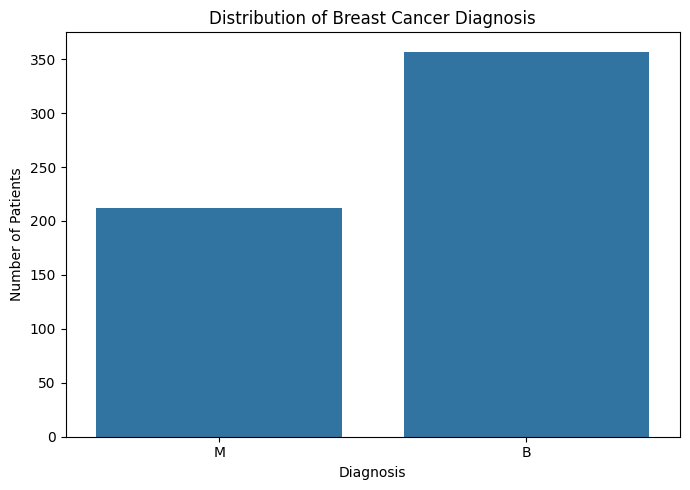


Target encoding:
B (Benign)     → 0
M (Malignant)  → 1

Encoded target distribution:
Target
0    357
1    212
Name: count, dtype: int64

Target encoding verified successfully.


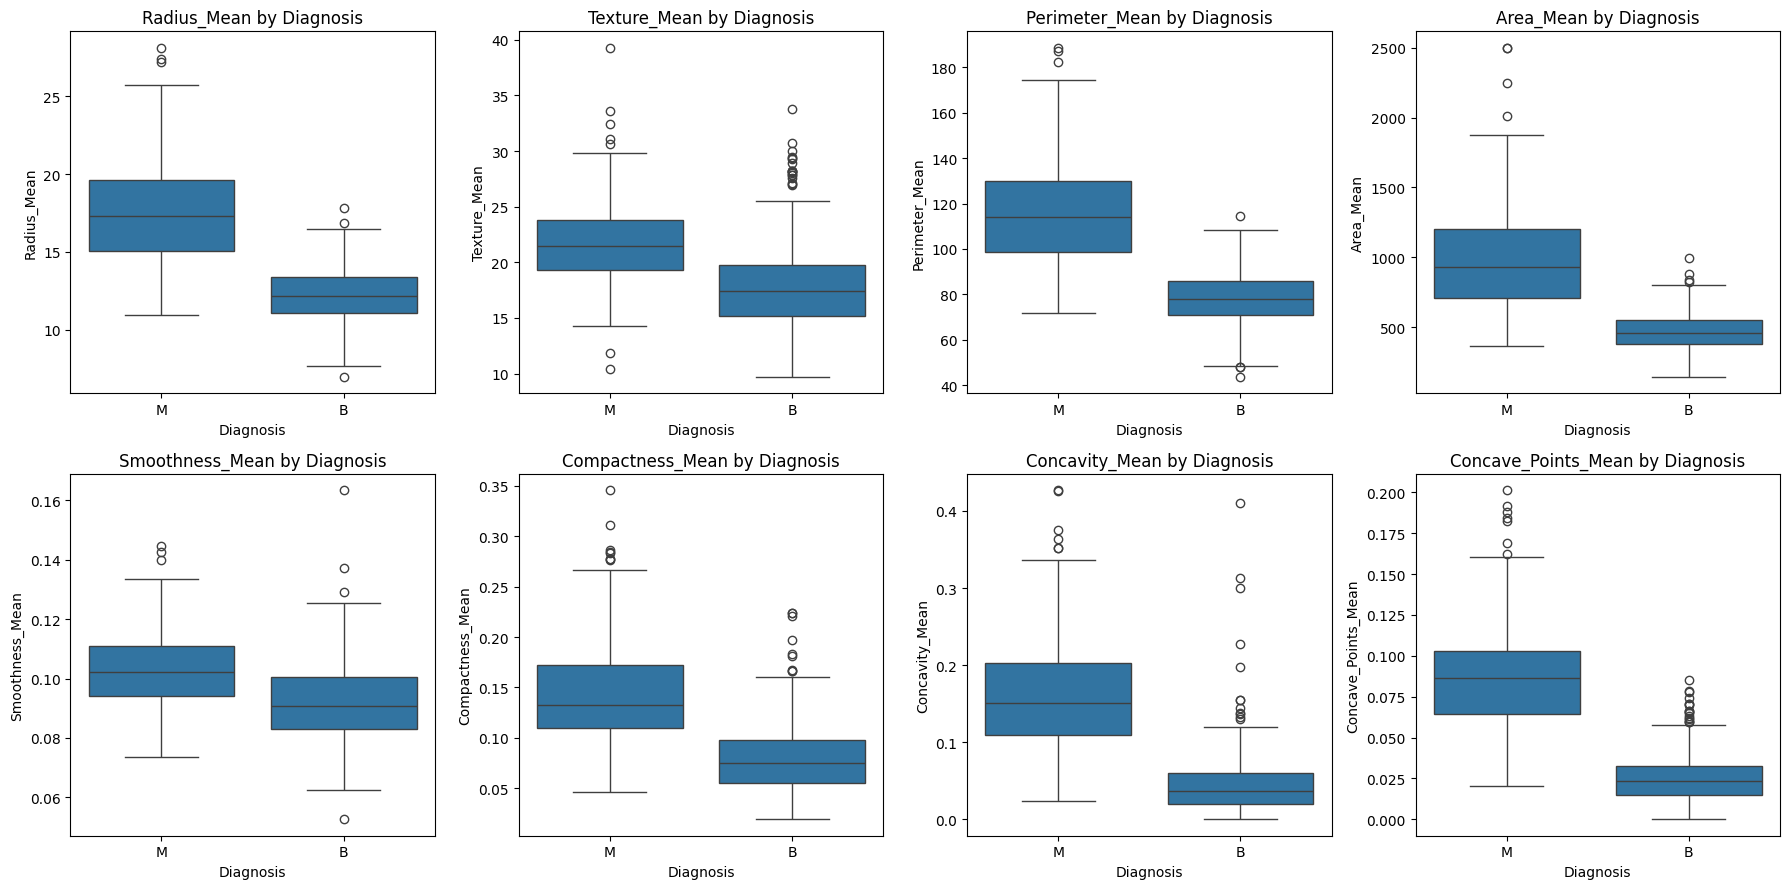

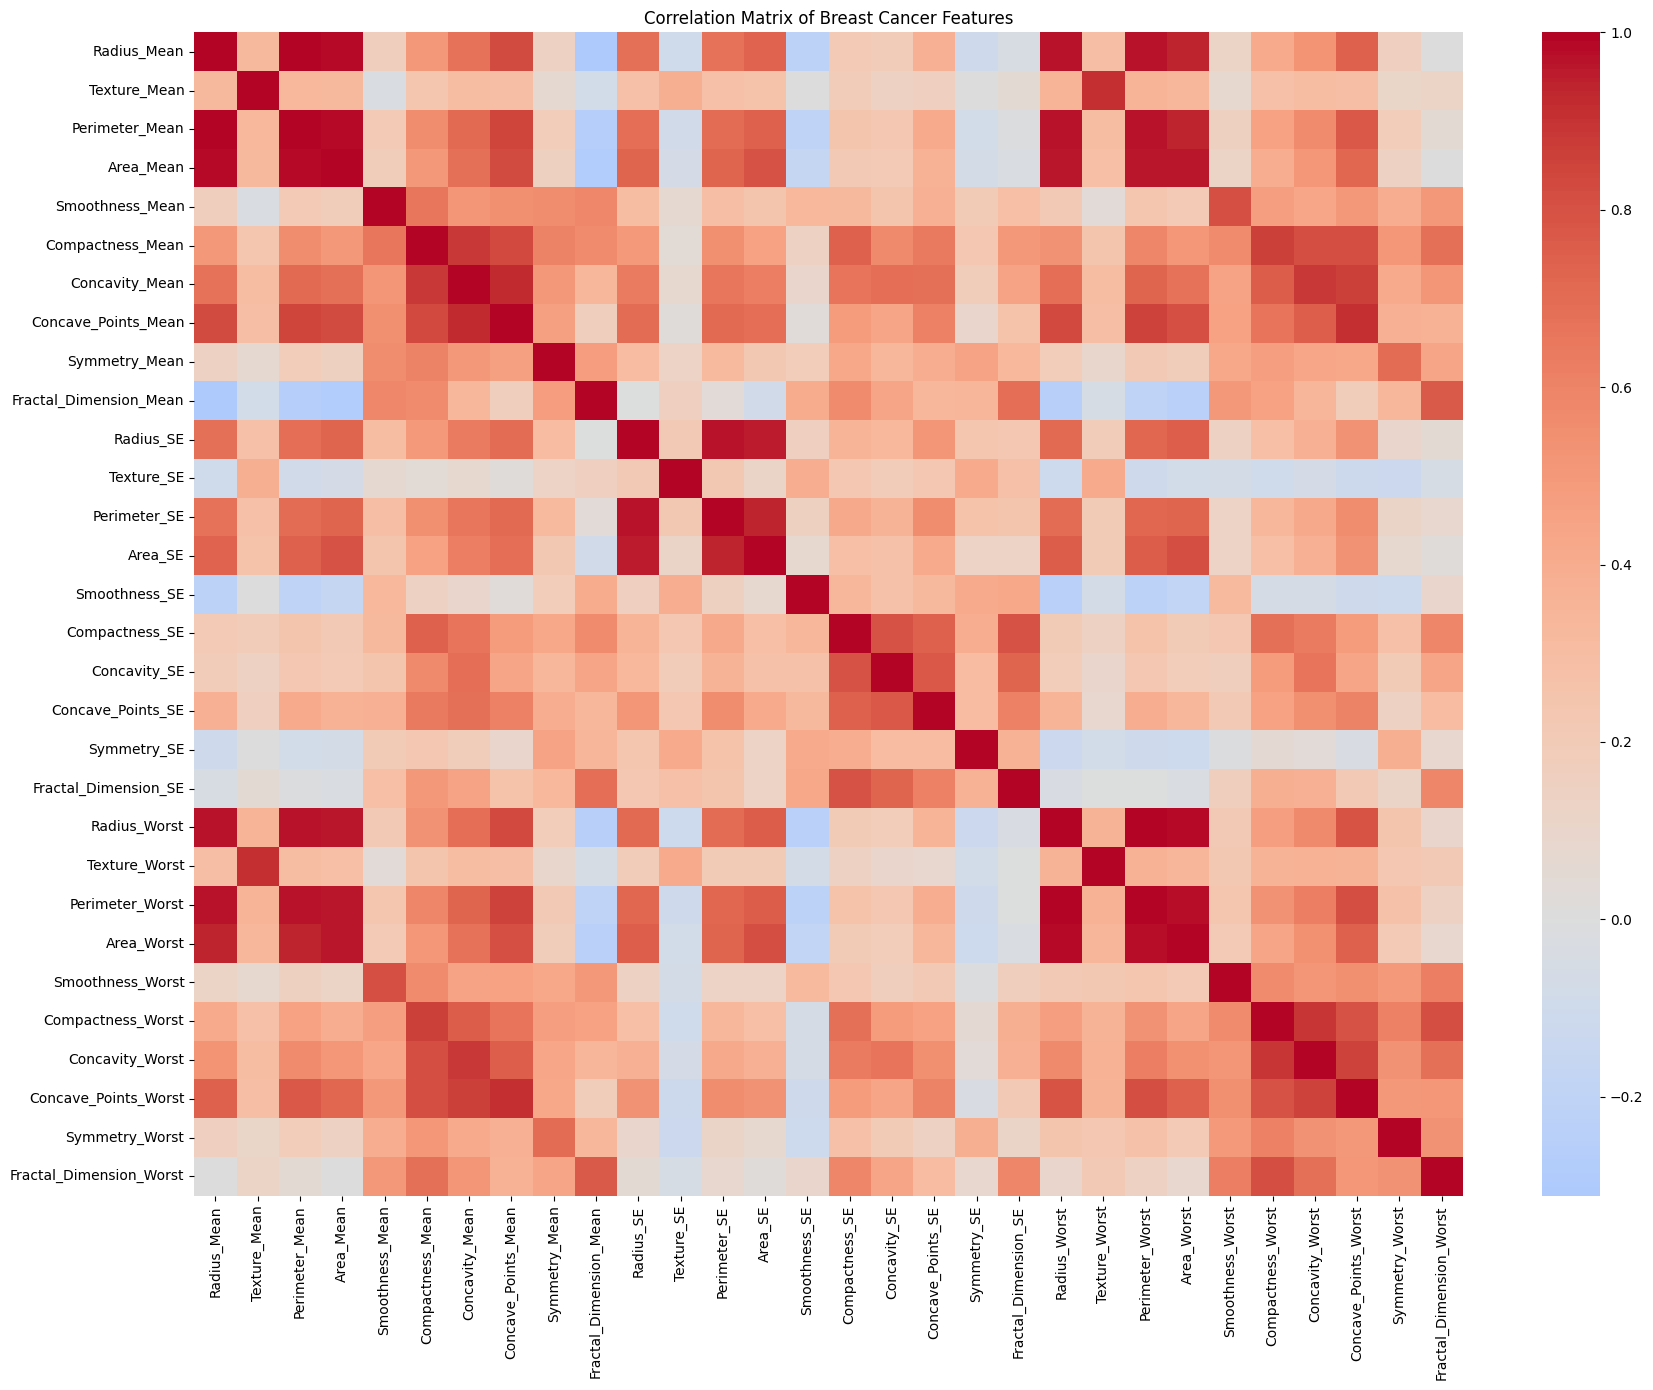


Feature matrix shape: (569, 30)
Target shape: (569,)

Number of features used: 30

Selected modeling features:
['Radius_Mean', 'Texture_Mean', 'Perimeter_Mean', 'Area_Mean', 'Smoothness_Mean', 'Compactness_Mean', 'Concavity_Mean', 'Concave_Points_Mean', 'Symmetry_Mean', 'Fractal_Dimension_Mean', 'Radius_SE', 'Texture_SE', 'Perimeter_SE', 'Area_SE', 'Smoothness_SE', 'Compactness_SE', 'Concavity_SE', 'Concave_Points_SE', 'Symmetry_SE', 'Fractal_Dimension_SE', 'Radius_Worst', 'Texture_Worst', 'Perimeter_Worst', 'Area_Worst', 'Smoothness_Worst', 'Compactness_Worst', 'Concavity_Worst', 'Concave_Points_Worst', 'Symmetry_Worst', 'Fractal_Dimension_Worst']

Training data shape: (455, 30)
Testing data shape: (114, 30)

Training class distribution:
Target
0    285
1    170
Name: count, dtype: int64

Testing class distribution:
Target
0    72
1    42
Name: count, dtype: int64

Logistic Regression pipeline created.
Logistic Regression model trained successfully.

Logistic Regression predictions g

,Metric,Logistic Regression
0,Accuracy,0.9649
1,Precision,0.9750
2,Recall,0.9286
3,F1 Score,0.9512
4,ROC-AUC,0.9960



Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



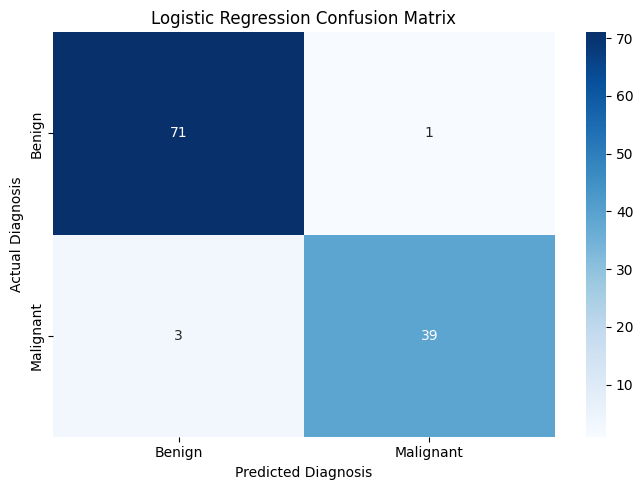


Random Forest model created.
Random Forest model trained successfully.

Random Forest predictions generated.

Random Forest Performance:


,Metric,Random Forest
0,Accuracy,0.9649
1,Precision,1.0000
2,Recall,0.9048
3,F1 Score,0.9500
4,ROC-AUC,0.9970



Random Forest Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



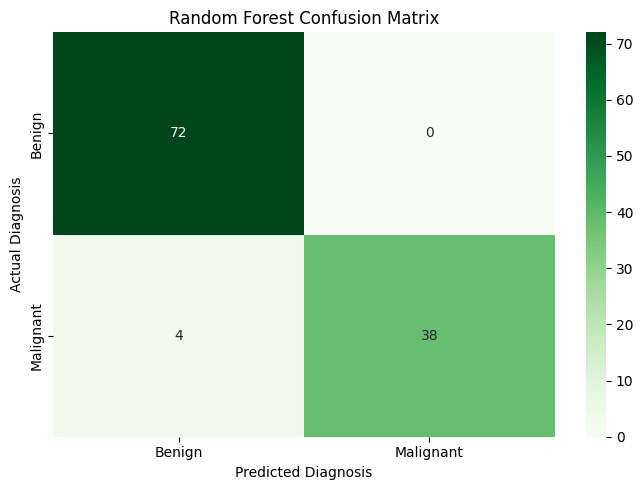


MODEL PERFORMANCE COMPARISON


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.9649,0.9649
1,Precision,0.9750,1.0000
2,Recall,0.9286,0.9048
3,F1 Score,0.9512,0.9500
4,ROC-AUC,0.9960,0.9970


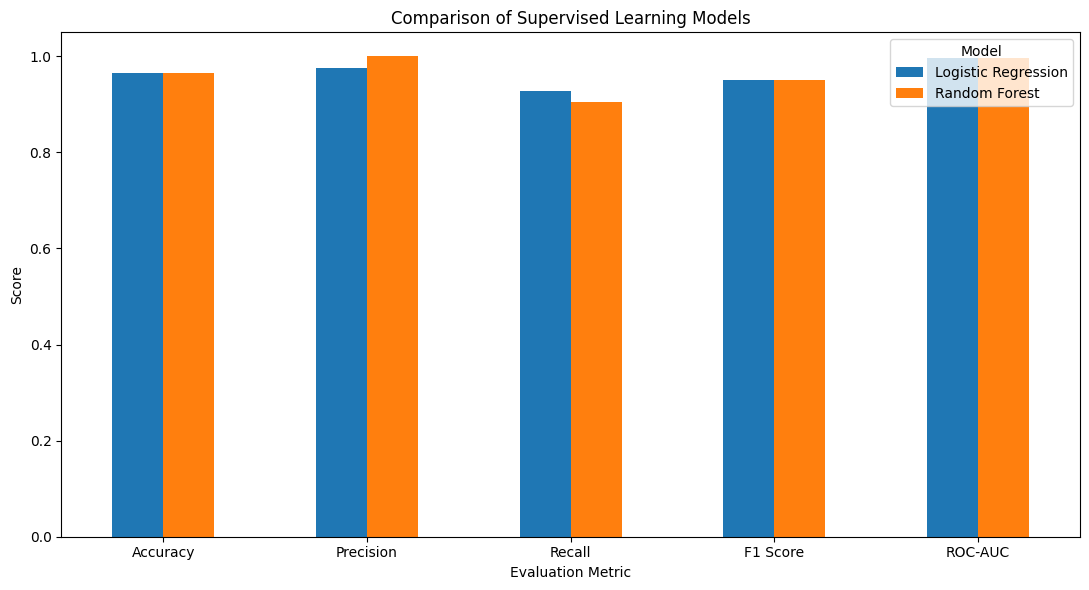


Logistic Regression 5-Fold CV Scores:
[0.9737 0.9474 0.9649 0.9912 0.9912]

Logistic Regression Mean CV Accuracy:
0.9737

Logistic Regression CV Standard Deviation:
0.0166

Random Forest 5-Fold CV Scores:
[0.9737 0.9474 0.9649 0.9561 0.9646]

Random Forest Mean CV Accuracy:
0.9613

Random Forest CV Standard Deviation:
0.0089

Cross-Validation Comparison:


,Model,Mean CV Accuracy,CV Std
0,Logistic Regression,0.9737,0.0166
1,Random Forest,0.9613,0.0089


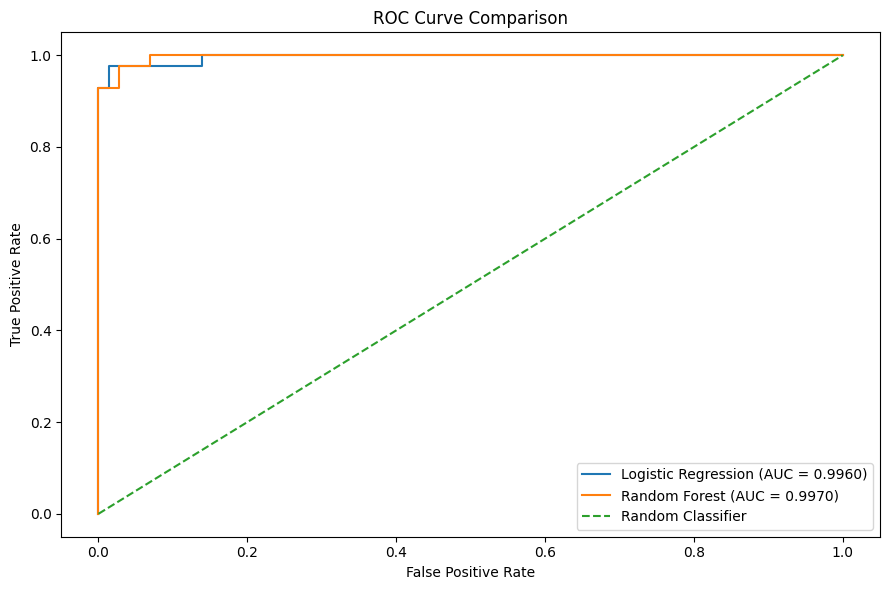


Top Logistic Regression Features:


,Feature,Coefficient,Absolute_Coefficient
21,Texture_Worst,1.4341,1.4341
10,Radius_SE,1.2333,1.2333
28,Symmetry_Worst,1.0613,1.0613
7,Concave_Points_Mean,0.9528,0.9528
26,Concavity_Worst,0.9114,0.9114
13,Area_SE,0.9090,0.9090
15,Compactness_SE,-0.9069,0.9069
23,Area_Worst,0.9005,0.9005
20,Radius_Worst,0.8970,0.8970
6,Concavity_Mean,0.7823,0.7823



Top Random Forest Features:


,Feature,Importance
22,Perimeter_Worst,0.1435
23,Area_Worst,0.1408
27,Concave_Points_Worst,0.1046
7,Concave_Points_Mean,0.0996
20,Radius_Worst,0.0750
0,Radius_Mean,0.0566
2,Perimeter_Mean,0.0514
6,Concavity_Mean,0.0482
26,Concavity_Worst,0.0391
3,Area_Mean,0.0383


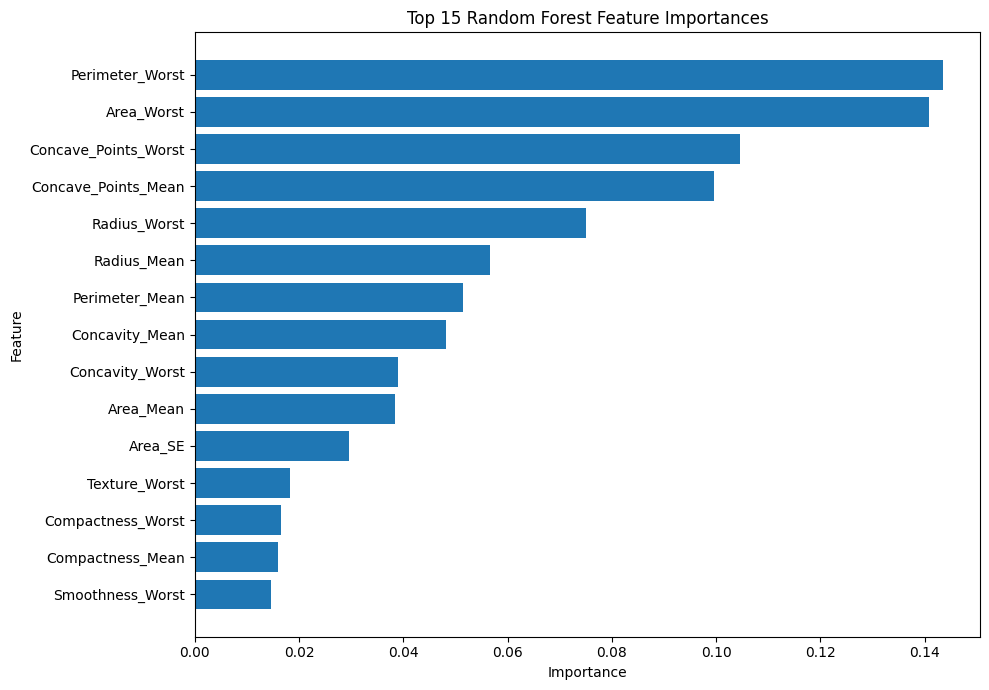


Logistic Regression incorrect predictions: 4
Random Forest incorrect predictions: 4

Logistic Regression errors:


,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,Radius_SE,Texture_SE,Perimeter_SE,Area_SE,Smoothness_SE,Compactness_SE,Concavity_SE,Concave_Points_SE,Symmetry_SE,Fractal_Dimension_SE,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst,Actual,Predicted_LR,Predicted_RF,LR_Correct,RF_Correct
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,0.3408,1.9240,2.287,28.93,0.005841,0.01246,0.007936,0.009128,0.01564,0.002985,15.05,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0,1,0,False,True
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,0.2787,0.6205,1.957,23.35,0.004717,0.02065,0.017590,0.009206,0.01220,0.003130,16.57,20.86,110.30,812.4,0.1411,0.3542,0.27790,0.13830,0.2589,0.10300,1,0,0,False,False
190,14.22,23.12,94.37,609.9,0.10750,0.24130,0.19810,0.06618,0.2384,0.07542,0.2860,2.1100,2.112,31.72,0.007970,0.13540,0.116600,0.016660,0.05113,0.011720,15.74,37.18,106.40,762.4,0.1533,0.9327,0.84880,0.17720,0.5166,0.14460,1,0,1,False,True
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,0.2711,0.3621,1.974,26.44,0.005472,0.01919,0.020390,0.008260,0.01523,0.002881,17.77,20.24,117.70,989.5,0.1491,0.3331,0.33270,0.12520,0.3415,0.09740,1,0,1,False,True



Best model based on test-set F1 Score:
Logistic Regression

FINAL MODEL PERFORMANCE
Best Model: Logistic Regression
Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
F1 Score:  0.9512
ROC-AUC:   0.9960

Prediction dataset:


,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,Radius_SE,Texture_SE,Perimeter_SE,Area_SE,Smoothness_SE,Compactness_SE,Concavity_SE,Concave_Points_SE,Symmetry_SE,Fractal_Dimension_SE,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst,Actual_Diagnosis,Predicted_Diagnosis,Malignant_Probability,Prediction_Correct
0,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,0.1408,0.4607,1.103,10.50,0.006040,0.01529,0.015140,0.006460,0.01344,0.002206,12.82,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,Benign,Benign,0.000365,True
1,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,1.0040,0.8208,6.372,137.90,0.005283,0.03908,0.095180,0.018640,0.02401,0.005002,25.58,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,Malignant,Malignant,1.000000,True
2,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,0.1745,0.4890,1.349,14.91,0.004510,0.01812,0.019510,0.011960,0.01934,0.003696,16.97,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,Benign,Benign,0.042568,True
3,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,0.2895,1.8510,2.376,26.85,0.008005,0.02895,0.033210,0.014240,0.01462,0.004452,16.33,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,Malignant,Malignant,0.576187,True
4,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,0.3408,1.9240,2.287,28.93,0.005841,0.01246,0.007936,0.009128,0.01564,0.002985,15.05,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,Benign,Malignant,0.509155,False



breast_cancer_predictions.csv saved successfully.
breast_cancer_dataset.csv saved successfully.
model_performance_comparison.csv saved successfully.
random_forest_feature_importance.csv saved successfully.

WEEK 4 PROJECT SUMMARY
Dataset size: 569 rows × 33 columns
Modeling features: 30
Training samples: 455
Testing samples: 114

Models:
1. Logistic Regression
2. Random Forest

Best Model: Logistic Regression

Best Model Metrics:
Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
F1 Score:  0.9512
ROC-AUC:   0.9960

Output files created:
✓ breast_cancer_dataset.csv
✓ breast_cancer_predictions.csv
✓ model_performance_comparison.csv
✓ random_forest_feature_importance.csv

Week 4 analysis completed successfully.


In [4]:
# ============================================================
# WEEK 4 – SUPERVISED LEARNING MODEL IMPLEMENTATION
# Breast Cancer Classification Using Machine Learning
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


# ============================================================
# 2. VERIFY UPLOADED FILES
# ============================================================

required_files = ["wdbc.data", "wdbc.names"]

print("\nChecking uploaded files...")

for file in required_files:
    if os.path.exists(file):
        print(f"✓ {file} found")
    else:
        print(f"✗ {file} not found")

if not all(os.path.exists(file) for file in required_files):
    raise FileNotFoundError(
        "Required dataset files are missing. Please upload wdbc.data and wdbc.names."
    )


# ============================================================
# 3. READ DATASET
# ============================================================

columns = [
    "ID",
    "Diagnosis",
    "Radius_Mean",
    "Texture_Mean",
    "Perimeter_Mean",
    "Area_Mean",
    "Smoothness_Mean",
    "Compactness_Mean",
    "Concavity_Mean",
    "Concave_Points_Mean",
    "Symmetry_Mean",
    "Fractal_Dimension_Mean",

    "Radius_SE",
    "Texture_SE",
    "Perimeter_SE",
    "Area_SE",
    "Smoothness_SE",
    "Compactness_SE",
    "Concavity_SE",
    "Concave_Points_SE",
    "Symmetry_SE",
    "Fractal_Dimension_SE",

    "Radius_Worst",
    "Texture_Worst",
    "Perimeter_Worst",
    "Area_Worst",
    "Smoothness_Worst",
    "Compactness_Worst",
    "Concavity_Worst",
    "Concave_Points_Worst",
    "Symmetry_Worst",
    "Fractal_Dimension_Worst"
]

df = pd.read_csv(
    "wdbc.data",
    header=None,
    names=columns
)

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)


# ============================================================
# 4. BASIC DATASET INSPECTION
# ============================================================

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset information:")
df.info()

print("\nDataset dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())


# ============================================================
# 5. DATA QUALITY ASSESSMENT
# ============================================================

print("\n" + "=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# Missing values
missing_values = df.isnull().sum()

print("\nMissing values:")
print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

# Duplicate records
duplicate_count = df.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)

# Data types
print("\nData types:")
print(df.dtypes)

# Unique diagnosis values
print("\nDiagnosis values:")
print(df["Diagnosis"].unique())

# ID uniqueness
print("\nUnique patient IDs:", df["ID"].nunique())

# Dataset summary
print("\nStatistical summary:")
display(df.describe())


# ============================================================
# 6. TARGET DISTRIBUTION
# ============================================================

diagnosis_counts = df["Diagnosis"].value_counts()

print("\nDiagnosis distribution:")
print(diagnosis_counts)

print("\nDiagnosis percentages:")
print(
    (df["Diagnosis"].value_counts(normalize=True) * 100).round(2)
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Diagnosis"
)

plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


# ============================================================
# 7. TARGET ENCODING
# ============================================================

# B = Benign = 0
# M = Malignant = 1

df["Target"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

print("\nTarget encoding:")
print("B (Benign)     → 0")
print("M (Malignant)  → 1")

print("\nEncoded target distribution:")
print(df["Target"].value_counts())


# ============================================================
# 8. CHECK TARGET ENCODING
# ============================================================

if df["Target"].isnull().sum() > 0:
    raise ValueError("Target encoding produced missing values.")

print("\nTarget encoding verified successfully.")


# ============================================================
# 9. EXPLORATORY DATA ANALYSIS
# ============================================================

# Mean feature distributions by diagnosis

selected_features = [
    "Radius_Mean",
    "Texture_Mean",
    "Perimeter_Mean",
    "Area_Mean",
    "Smoothness_Mean",
    "Compactness_Mean",
    "Concavity_Mean",
    "Concave_Points_Mean"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, feature in zip(axes.flatten(), selected_features):

    sns.boxplot(
        data=df,
        x="Diagnosis",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} by Diagnosis")
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


# ============================================================
# 10. CORRELATION ANALYSIS
# ============================================================

numeric_features = df.drop(
    columns=["ID", "Diagnosis", "Target"]
)

correlation_matrix = numeric_features.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Breast Cancer Features")
plt.tight_layout()
plt.show()


# ============================================================
# 11. FEATURE SELECTION
# ============================================================

# ID is an identifier and does not contain predictive information.
# Diagnosis is the original categorical target.
# Target is the numerical target created for modeling.

X = df.drop(
    columns=["ID", "Diagnosis", "Target"]
)

y = df["Target"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumber of features used:", X.shape[1])

print("\nSelected modeling features:")
print(X.columns.tolist())


# ============================================================
# 12. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


# ============================================================
# 13. LOGISTIC REGRESSION PIPELINE
# ============================================================

# StandardScaler is placed inside the pipeline.
# This ensures scaling is learned only from training data.

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

print("\nLogistic Regression pipeline created.")


# ============================================================
# 14. TRAIN LOGISTIC REGRESSION
# ============================================================

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")


# ============================================================
# 15. LOGISTIC REGRESSION PREDICTIONS
# ============================================================

y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression predictions generated.")


# ============================================================
# 16. LOGISTIC REGRESSION EVALUATION
# ============================================================

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

lr_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_roc_auc
    ]
})

print("\nLogistic Regression Performance:")
display(lr_results.round(4))


# ============================================================
# 17. LOGISTIC REGRESSION CLASSIFICATION REPORT
# ============================================================

print("\nLogistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Benign", "Malignant"]
    )
)


# ============================================================
# 18. LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()


# ============================================================
# 19. RANDOM FOREST MODEL
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

print("\nRandom Forest model created.")


# ============================================================
# 20. TRAIN RANDOM FOREST
# ============================================================

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")


# ============================================================
# 21. RANDOM FOREST PREDICTIONS
# ============================================================

y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest predictions generated.")


# ============================================================
# 22. RANDOM FOREST EVALUATION
# ============================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

print("\nRandom Forest Performance:")
display(rf_results.round(4))


# ============================================================
# 23. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Benign", "Malignant"]
    )
)


# ============================================================
# 24. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()


# ============================================================
# 25. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

display(comparison.round(4))


# ============================================================
# 26. PERFORMANCE COMPARISON GRAPH
# ============================================================

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of Supervised Learning Models")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# ============================================================
# 27. STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

rf_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nLogistic Regression 5-Fold CV Scores:")
print(np.round(lr_cv_scores, 4))

print("\nLogistic Regression Mean CV Accuracy:")
print(round(lr_cv_scores.mean(), 4))

print("\nLogistic Regression CV Standard Deviation:")
print(round(lr_cv_scores.std(), 4))

print("\nRandom Forest 5-Fold CV Scores:")
print(np.round(rf_cv_scores, 4))

print("\nRandom Forest Mean CV Accuracy:")
print(round(rf_cv_scores.mean(), 4))

print("\nRandom Forest CV Standard Deviation:")
print(round(rf_cv_scores.std(), 4))


# ============================================================
# 28. CROSS-VALIDATION COMPARISON
# ============================================================

cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Mean CV Accuracy": [
        lr_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "CV Std": [
        lr_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

print("\nCross-Validation Comparison:")
display(cv_comparison.round(4))


# ============================================================
# 29. ROC CURVE
# ============================================================

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 30. LOGISTIC REGRESSION FEATURE COEFFICIENTS
# ============================================================

# Extract coefficients from the fitted pipeline

lr_classifier = logistic_model.named_steps["classifier"]

lr_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_classifier.coef_[0]
})

lr_coefficients["Absolute_Coefficient"] = (
    lr_coefficients["Coefficient"].abs()
)

lr_coefficients = lr_coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\nTop Logistic Regression Features:")
display(
    lr_coefficients.head(15).round(4)
)


# ============================================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop Random Forest Features:")
display(
    feature_importance.head(15).round(4)
)


# ============================================================
# 32. RANDOM FOREST FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# ============================================================
# 33. MODEL ERROR ANALYSIS
# ============================================================

error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted_LR"] = y_pred_lr
error_analysis["Predicted_RF"] = y_pred_rf

error_analysis["LR_Correct"] = (
    error_analysis["Actual"] ==
    error_analysis["Predicted_LR"]
)

error_analysis["RF_Correct"] = (
    error_analysis["Actual"] ==
    error_analysis["Predicted_RF"]
)

print("\nLogistic Regression incorrect predictions:",
      (~error_analysis["LR_Correct"]).sum())

print("Random Forest incorrect predictions:",
      (~error_analysis["RF_Correct"]).sum())

print("\nLogistic Regression errors:")
display(
    error_analysis[
        ~error_analysis["LR_Correct"]
    ].head(10)
)


# ============================================================
# 34. SELECT BEST MODEL
# ============================================================

# Primary selection criterion:
# F1 Score, because both false positives and false negatives
# are important in a binary classification problem.

if rf_f1 > lr_f1:
    best_model_name = "Random Forest"
    best_model = random_forest_model
    best_predictions = y_pred_rf
    best_probabilities = y_prob_rf
else:
    best_model_name = "Logistic Regression"
    best_model = logistic_model
    best_predictions = y_pred_lr
    best_probabilities = y_prob_lr

print("\nBest model based on test-set F1 Score:")
print(best_model_name)


# ============================================================
# 35. FINAL MODEL METRICS
# ============================================================

if best_model_name == "Random Forest":
    best_accuracy = rf_accuracy
    best_precision = rf_precision
    best_recall = rf_recall
    best_f1 = rf_f1
    best_auc = rf_roc_auc
else:
    best_accuracy = lr_accuracy
    best_precision = lr_precision
    best_recall = lr_recall
    best_f1 = lr_f1
    best_auc = lr_roc_auc

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print("Best Model:", best_model_name)
print(f"Accuracy:  {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"F1 Score:  {best_f1:.4f}")
print(f"ROC-AUC:   {best_auc:.4f}")


# ============================================================
# 36. CREATE PREDICTIONS DATASET
# ============================================================

predictions_df = X_test.copy()

predictions_df["Actual_Diagnosis"] = y_test.map({
    0: "Benign",
    1: "Malignant"
}).values

predictions_df["Predicted_Diagnosis"] = pd.Series(
    best_predictions,
    index=X_test.index
).map({
    0: "Benign",
    1: "Malignant"
}).values

predictions_df["Malignant_Probability"] = best_probabilities

predictions_df["Prediction_Correct"] = (
    predictions_df["Actual_Diagnosis"] ==
    predictions_df["Predicted_Diagnosis"]
)

predictions_df = predictions_df.reset_index(drop=True)

print("\nPrediction dataset:")
display(predictions_df.head())


# ============================================================
# 37. SAVE PREDICTIONS
# ============================================================

predictions_df.to_csv(
    "breast_cancer_predictions.csv",
    index=False
)

print(
    "\nbreast_cancer_predictions.csv saved successfully."
)


# ============================================================
# 38. SAVE CLEAN DATASET USED FOR MODELING
# ============================================================

# Save the original dataset with the encoded target.
# This preserves the exact dataset used in the project.

df.to_csv(
    "breast_cancer_dataset.csv",
    index=False
)

print(
    "breast_cancer_dataset.csv saved successfully."
)


# ============================================================
# 39. SAVE MODEL COMPARISON
# ============================================================

comparison.to_csv(
    "model_performance_comparison.csv",
    index=False
)

print(
    "model_performance_comparison.csv saved successfully."
)


# ============================================================
# 40. SAVE FEATURE IMPORTANCE
# ============================================================

feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print(
    "random_forest_feature_importance.csv saved successfully."
)


# ============================================================
# 41. FINAL PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("WEEK 4 PROJECT SUMMARY")
print("=" * 70)

print(f"Dataset size: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Modeling features: {X.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

print("\nModels:")
print("1. Logistic Regression")
print("2. Random Forest")

print("\nBest Model:", best_model_name)

print("\nBest Model Metrics:")
print(f"Accuracy:  {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"F1 Score:  {best_f1:.4f}")
print(f"ROC-AUC:   {best_auc:.4f}")

print("\nOutput files created:")
print("✓ breast_cancer_dataset.csv")
print("✓ breast_cancer_predictions.csv")
print("✓ model_performance_comparison.csv")
print("✓ random_forest_feature_importance.csv")

print("\nWeek 4 analysis completed successfully.")

## Conclusion

This project successfully implemented a supervised learning workflow for breast cancer diagnosis using the Wisconsin Diagnostic Breast Cancer dataset. The process covered data inspection, quality assessment, exploratory analysis, target encoding, feature selection, preprocessing, model training, validation, and performance evaluation.

Logistic Regression was implemented as the primary classification model, while Random Forest was used as a comparison model. The models were evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC, confusion matrices, ROC curves, and 5-fold stratified cross-validation. These evaluation techniques provided a comprehensive assessment of predictive performance and helped identify the stronger model for the classification task.

Feature analysis was also performed to understand which measurements contributed most to the predictions. The results demonstrate how supervised machine learning can be applied to distinguish benign and malignant cases using numerical diagnostic features.

Overall, the project demonstrates a complete and reproducible machine learning pipeline in Python, from raw data preparation to model evaluation and prediction generation. The analysis also highlights the importance of appropriate preprocessing, model validation, multiple evaluation metrics, and feature interpretation when developing classification models. While the models provide useful predictive performance on this dataset, further improvements could be explored through hyperparameter tuning, feature selection, ensemble methods, and additional validation on independent datasets.